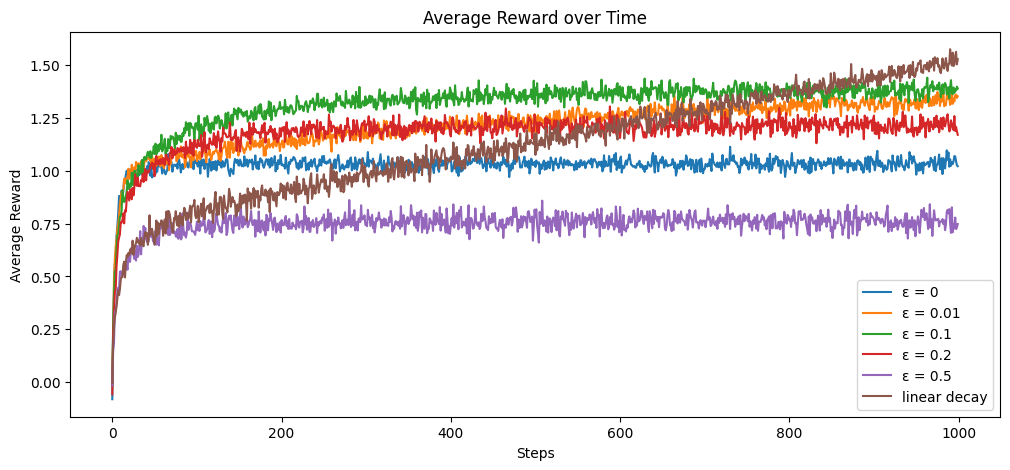

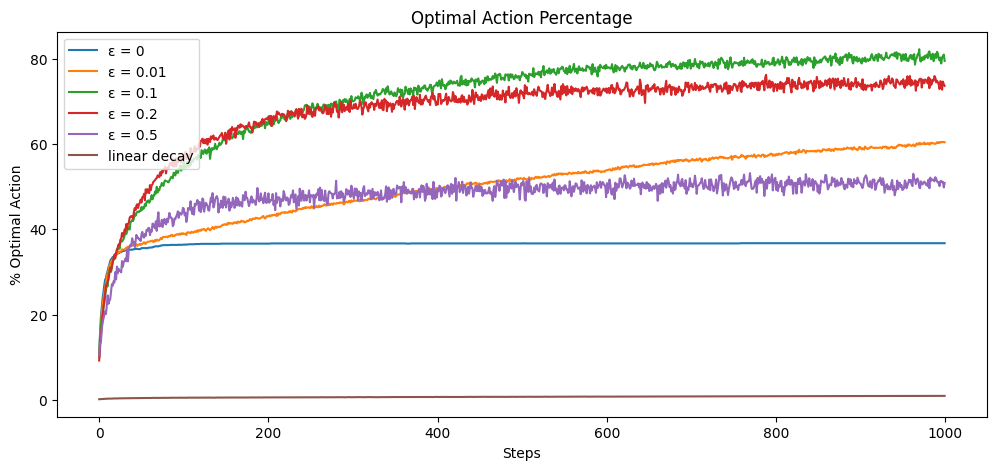

In [12]:
import numpy as np
import matplotlib.pyplot as plt

class TenArmedTestbed:
    def __init__(self, k=10):
        self.k = k
        self.q_true = np.random.normal(0, 1, k)  # True action values
        self.optimal_action = np.argmax(self.q_true)

    def step(self, action):
        """Take action and return reward."""
        return np.random.normal(self.q_true[action], 1)


def epsilon_greedy(Q, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(len(Q))
    return np.argmax(Q)


def run_bandit(epsilon, runs=2000, steps=1000):
    avg_rewards = np.zeros(steps)
    optimal_action_counts = np.zeros(steps)

    for _ in range(runs):
        bandit = TenArmedTestbed()
        Q = np.zeros(bandit.k)
        N = np.zeros(bandit.k)

        for t in range(steps):
            action = epsilon_greedy(Q, epsilon)
            reward = bandit.step(action)

            N[action] += 1
            Q[action] += (reward - Q[action]) / N[action]

            avg_rewards[t] += reward
            if action == bandit.optimal_action:
                optimal_action_counts[t] += 1

    avg_rewards /= runs
    optimal_action_counts /= runs

    return avg_rewards, optimal_action_counts


def run_bandit2(epsilon, runs=2000, steps=1000):
    avg_rewards = np.zeros(steps)
    optimal_action_counts = np.zeros(steps)

    for _ in range(runs):
        bandit = TenArmedTestbed()
        Q = np.zeros(bandit.k)
        N = np.zeros(bandit.k)

        eps = epsilon
        delta_eps = epsilon / float(steps)

        for t in range(steps):
            action = epsilon_greedy(Q, eps)
            reward = bandit.step(action)

            N[action] += 1
            Q[action] += (reward - Q[action]) / N[action]

            avg_rewards[t] += reward
            if action == bandit.optimal_action:
                optimal_action_counts[t] += 1

            eps -= delta_eps

    avg_rewards /= runs
    optimal_action_counts /= runs

    return avg_rewards, optimal_action_counts


# ---- Run experiments ----
epsilons = [0, 0.01, 0.1, 0.2, 0.5]
results = {}

for eps in epsilons:
    rewards, optimal = run_bandit(eps)
        
    results[eps] = (rewards, optimal)

rewards2, optimal2 = run_bandit2(0.5)

# ---- Plot Average Reward ----
plt.figure(figsize=(12,5))
for eps in epsilons:
    plt.plot(results[eps][0], label=f"ε = {eps}")
plt.plot(rewards2, label=f"linear decay")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Average Reward over Time")
plt.legend()
plt.savefig("mab-rewards.svg")
plt.show()


# ---- Plot Optimal Action Percentage ----
plt.figure(figsize=(12,5))
for eps in epsilons:
    plt.plot(results[eps][1] * 100, label=f"ε = {eps}")
plt.plot(optimal2, label=f"linear decay")
plt.xlabel("Steps")
plt.ylabel("% Optimal Action")
plt.title("Optimal Action Percentage")
plt.legend()
plt.savefig("mab-actions.svg")
plt.show()

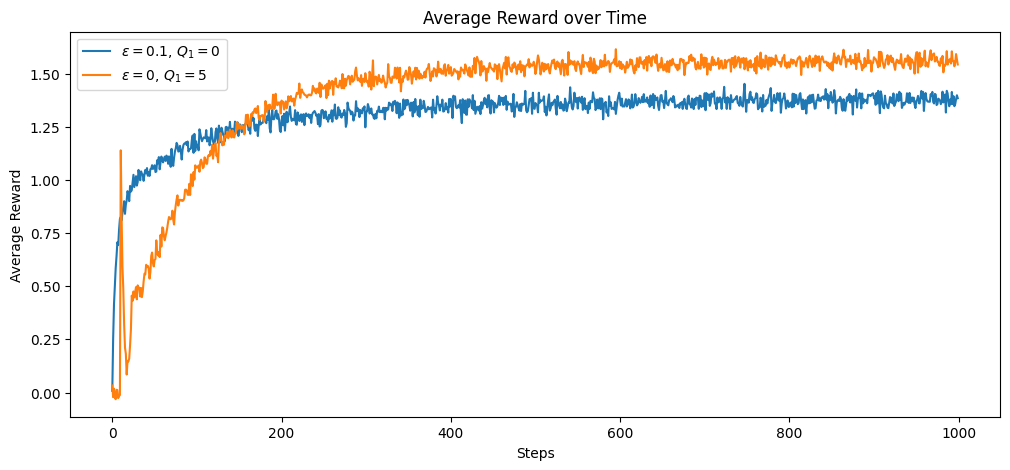

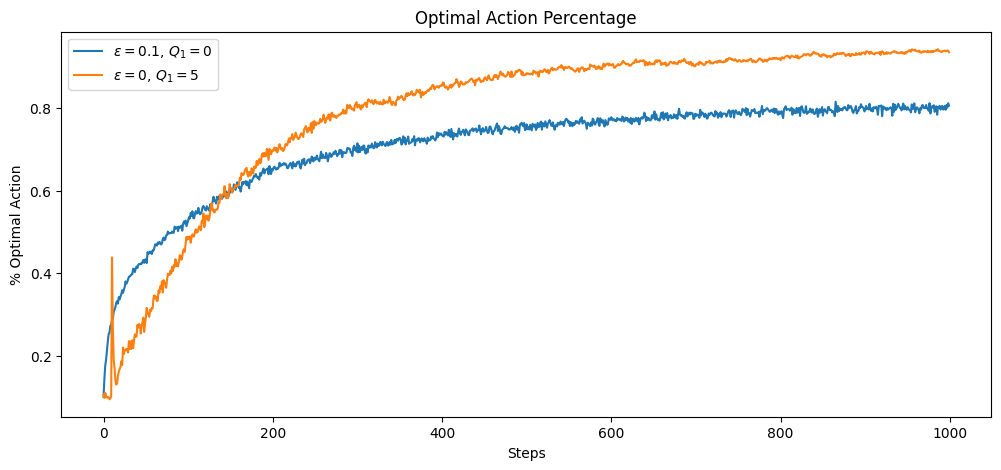

In [22]:
def run_bandit_optimistic(epsilon, runs=2000, steps=1000, val_opt=0.0):
    avg_rewards = np.zeros(steps)
    optimal_action_counts = np.zeros(steps)

    for _ in range(runs):
        bandit = TenArmedTestbed()
        Q = val_opt * np.ones(bandit.k)
        N = val_opt * np.ones(bandit.k)

        for t in range(steps):
            action = epsilon_greedy(Q, epsilon)
            reward = bandit.step(action)

            N[action] += 1
            Q[action] += (reward - Q[action]) / N[action]

            avg_rewards[t] += reward
            if action == bandit.optimal_action:
                optimal_action_counts[t] += 1

    avg_rewards /= runs
    optimal_action_counts /= runs

    return avg_rewards, optimal_action_counts


# ---- Run experiments ----
rewards, optimal = run_bandit_optimistic(0.1, runs=2000, steps=1000, val_opt=0.0)
rewards_opt, optimal_opt = run_bandit_optimistic(0.0, runs=2000, steps=1000, val_opt=5.0)


# ---- Plot Average Reward ----
plt.figure(figsize=(12,5))
plt.plot(rewards, label=r"$\epsilon = 0.1$, $Q_1 = 0$")
plt.plot(rewards_opt, label=r"$\epsilon = 0$, $Q_1 = 5$")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Average Reward over Time")
plt.legend()
plt.savefig("mab-rewards-opt.svg")
plt.show()

# ---- Plot Optimal Action Percentage ----
plt.figure(figsize=(12,5))
plt.plot(optimal, label=r"$\epsilon = 0.1$, $Q_1 = 0$")
plt.plot(optimal_opt, label=r"$\epsilon = 0$, $Q_1 = 5$")
plt.xlabel("Steps")
plt.ylabel("% Optimal Action")
plt.title("Optimal Action Percentage")
plt.legend()
plt.savefig("mab-actions-opt.svg")
plt.show()